In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = Path('../data/prevalence_of_chikungunya.csv')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

In [82]:
# Load the dataset
def load_data():
    df = pd.read_csv(DATA_PATH, encoding='UTF-8')
    print(f'Dataset shape: {df.shape}')
    #print(f'Dataset columns: {df.columns.tolist()}')
    #print(df.head())
    return df

# Clean the dataset
def clean_data(df):
    df.columns = df.columns.str.lower().str.replace(' ','_')
    df.columns = df.columns.str.replace('[^a-zA-Z0-9_]','', regex=True)
    df.replace(['-', ''], np.nan, inplace=True)

In [83]:
#data cleaning
df = load_data()
df.columns = df.columns.str.lower().str.replace(' ','_')
df.columns = df.columns.str.replace('[^a-zA-Z0-9_]','', regex=True)
#Filling Nan for empty values
df.replace(['-', ''], np.nan, inplace=True)
df
    


Dataset shape: (30, 52)


,timestamp,age,sex,residence,occupation,socioeconomic_status,onset_date,onset_to_admission_duration_in_days,presenting_symptoms,pattern,...,icu_admission,mortality,cause_of_death,length_of_stay,readmission_within_30_days,functional_status_at_discharge,duration,inotropic_support,mechanical_ventilation,renal_replacement_therapy
0,2025/10/08 1:41:40 AM GMT+5:30,57,Male,Local,NaN,NaN,25/12/2023,7.0,Fever;Arthralgia/Arthritis;Myalgia,NaN,...,Yes,No,NaN,13.0,No,Assisted,13.0,Yes,Yes,No
1,2025/10/08 1:49:35 AM GMT+5:30,77,Male,Local,NaN,NaN,08/04/2024,1.0,Arthralgia/Arthritis,NaN,...,No,No,NaN,NaN,No,Independent,NaN,No,No,No
2,2025/10/08 1:54:41 AM GMT+5:30,55,Male,Local,NaN,NaN,3/05/25,3.0,Fever;Arthralgia/Arthritis;Myalgia,NaN,...,No,No,NaN,NaN,No,Independent,NaN,No,No,No
3,2025/10/08 2:31:14 AM GMT+5:30,54,Female,Local,NaN,NaN,NaN,NaN,Arthralgia/Arthritis,NaN,...,Yes,No,NaN,8.0,No,Independent,6.0,Yes,No,No
4,2025/10/08 2:40:36 AM GMT+5:30,65,Female,Local,NaN,NaN,12/06/24,3.0,Arthralgia/Arthritis;Myalgia;Conjunctivitis,NaN,...,No,No,NaN,4.0,No,Independent,NaN,No,No,No
5,2025/10/08 2:50:09 AM GMT+5:30,34,Female,Local,NaN,NaN,NaN,NaN,Arthralgia/Arthritis,NaN,...,No,No,NaN,3.0,No,Independent,NaN,No,No,No
6,2025/10/08 3:00:38 AM GMT+5:30,25,Female,Native of non endemic area,NaN,NaN,1/07/24,2.0,Fever;Arthralgia/Arthritis;Rash;Myalgia,Symmetric,...,No,No,NaN,14.0,No,Independent,NaN,No,No,No
7,2025/10/08 4:28:50 AM GMT+5:30,68,Male,Local,NaN,NaN,11/07/24,7.0,Fever;Arthralgia/Arthritis;Rash;Headache,Symmetric,...,No,No,NaN,3.0,No,Independent,NaN,No,No,No
8,2025/10/08 4:34:32 AM GMT+5:30,82,Female,Local,NaN,NaN,16/07/24,2.0,Fever;Arthralgia/Arthritis;Rash;Myalgia,Symmetric,...,No,No,NaN,5.0,No,Independent,NaN,No,No,No
9,2025/10/08 4:40:25 AM GMT+5:30,41,Female,Local,NaN,NaN,NaN,NaN,Nausea/Vomitting,NaN,...,No,No,NaN,1.0,No,Independent,NaN,No,No,No


In [84]:
for col in df.columns:
    #print(f'\n{col}')
    print(f'\n{df[col].value_counts(dropna=False)}')


timestamp
2025/10/08 1:41:40 AM GMT+5:30     1
2025/10/08 1:49:35 AM GMT+5:30     1
2025/10/11 4:24:01 AM GMT+5:30     1
2025/10/11 4:20:09 AM GMT+5:30     1
2025/10/11 4:16:20 AM GMT+5:30     1
2025/10/11 4:10:28 AM GMT+5:30     1
2025/10/11 4:05:30 AM GMT+5:30     1
2025/10/11 3:48:26 AM GMT+5:30     1
2025/10/11 3:45:39 AM GMT+5:30     1
2025/10/11 3:38:48 AM GMT+5:30     1
2025/10/11 3:34:06 AM GMT+5:30     1
2025/10/11 12:56:55 AM GMT+5:30    1
2025/10/11 12:51:16 AM GMT+5:30    1
2025/10/11 12:44:42 AM GMT+5:30    1
2025/10/11 12:38:43 AM GMT+5:30    1
2025/10/11 12:33:30 AM GMT+5:30    1
2025/10/08 10:19:24 AM GMT+5:30    1
2025/10/08 10:10:38 AM GMT+5:30    1
2025/10/08 10:04:11 AM GMT+5:30    1
2025/10/08 9:57:29 AM GMT+5:30     1
2025/10/08 9:51:30 AM GMT+5:30     1
2025/10/08 4:40:25 AM GMT+5:30     1
2025/10/08 4:34:32 AM GMT+5:30     1
2025/10/08 4:28:50 AM GMT+5:30     1
2025/10/08 3:00:38 AM GMT+5:30     1
2025/10/08 2:50:09 AM GMT+5:30     1
2025/10/08 2:40:36 AM GMT+5

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 52 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   timestamp                            30 non-null     object 
 1   age                                  30 non-null     int64  
 2   sex                                  30 non-null     object 
 3   residence                            30 non-null     object 
 4   occupation                           0 non-null      float64
 5   socioeconomic_status                 0 non-null      float64
 6   onset_date                           25 non-null     object 
 7   onset_to_admission_duration_in_days  25 non-null     float64
 8   presenting_symptoms                  30 non-null     object 
 9   pattern                              19 non-null     object 
 10  number_of_joints                     19 non-null     float64
 11  pain_vas_score                    

In [86]:
df.describe()

,age,occupation,socioeconomic_status,onset_to_admission_duration_in_days,number_of_joints,pain_vas_score,pulse,respiratory_rate,chronic,length_of_stay,duration
count,30.000000,0.0,0.0,25.000000,19.000000,0.0,30.000000,30.000000,0.0,27.000000,2.000000
mean,55.300000,NaN,NaN,3.160000,3.157895,NaN,83.166667,18.000000,NaN,4.592593,9.500000
std,19.500928,NaN,NaN,2.967603,1.213954,NaN,12.945731,2.100903,NaN,3.003322,4.949747
min,22.000000,NaN,NaN,1.000000,2.000000,NaN,55.000000,14.000000,NaN,1.000000,6.000000
25%,40.250000,NaN,NaN,2.000000,2.000000,NaN,80.000000,16.000000,NaN,3.000000,7.750000
50%,59.500000,NaN,NaN,2.000000,4.000000,NaN,83.000000,18.000000,NaN,4.000000,9.500000
75%,71.000000,NaN,NaN,4.000000,4.000000,NaN,86.000000,20.000000,NaN,5.000000,11.250000
max,85.000000,NaN,NaN,15.000000,6.000000,NaN,119.000000,22.000000,NaN,14.000000,13.000000


In [ ]:
# Pasring date columns
#date_cols = ['timestamp', 'onset_date']
#for col in date_cols:
#    df[col] = pd.to_datetime(df[col], errors='coerce')

In [87]:
# Converting numerics
numeric_cols = ['age', 'onset_to_admission_duration_in_days', 'number_of_joints', 'pulse', 'spo2', 'respiratory_rate', 'length_of_stay']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 52 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   timestamp                            30 non-null     object 
 1   age                                  30 non-null     int64  
 2   sex                                  30 non-null     object 
 3   residence                            30 non-null     object 
 4   occupation                           0 non-null      float64
 5   socioeconomic_status                 0 non-null      float64
 6   onset_date                           25 non-null     object 
 7   onset_to_admission_duration_in_days  25 non-null     float64
 8   presenting_symptoms                  30 non-null     object 
 9   pattern                              19 non-null     object 
 10  number_of_joints                     19 non-null     float64
 11  pain_vas_score                    

In [ ]:
#drop_cols = ['renal_replacement_therapy', 'mechanical_ventilation', 'inotropic_support', 'duration', 'functional_status_at_discharge', 
#                     'readmission_within_30_days', 'cause_of_death', 'mortality', 'dmards', 'chronic', 'complications1', 'prior_dengue', 
#                     'complications', 'prior_chikungunya', 'pain_vas_score', 'occupation', 'socioeconomic_status']
#df = df.drop(columns=drop_cols)


In [90]:
from dateutil.parser import parse

def parse_flexible_date(date_str):
    if pd.isna(date_str):
        return pd.NaT
    try:
        # Use dateutil for flexible parsing, with dayfirst for dd/mm format
        return pd.to_datetime(parse(str(date_str), dayfirst=True))
    except:
        return pd.NaT

plot symptoms distribution

plot duration distribution

plot dates (find season)

male / female dist

age dist

In [91]:
# Apply the flexible date parser to the relevant columns
df['onset_date'] = df['onset_date'].apply(parse_flexible_date)
df

,timestamp,age,sex,residence,occupation,socioeconomic_status,onset_date,onset_to_admission_duration_in_days,presenting_symptoms,pattern,...,icu_admission,mortality,cause_of_death,length_of_stay,readmission_within_30_days,functional_status_at_discharge,duration,inotropic_support,mechanical_ventilation,renal_replacement_therapy
0,2025/10/08 1:41:40 AM GMT+5:30,57,Male,Local,NaN,NaN,2023-12-25,7.0,Fever;Arthralgia/Arthritis;Myalgia,NaN,...,Yes,No,NaN,13.0,No,Assisted,13.0,Yes,Yes,No
1,2025/10/08 1:49:35 AM GMT+5:30,77,Male,Local,NaN,NaN,2024-04-08,1.0,Arthralgia/Arthritis,NaN,...,No,No,NaN,NaN,No,Independent,NaN,No,No,No
2,2025/10/08 1:54:41 AM GMT+5:30,55,Male,Local,NaN,NaN,2025-05-03,3.0,Fever;Arthralgia/Arthritis;Myalgia,NaN,...,No,No,NaN,NaN,No,Independent,NaN,No,No,No
3,2025/10/08 2:31:14 AM GMT+5:30,54,Female,Local,NaN,NaN,NaT,NaN,Arthralgia/Arthritis,NaN,...,Yes,No,NaN,8.0,No,Independent,6.0,Yes,No,No
4,2025/10/08 2:40:36 AM GMT+5:30,65,Female,Local,NaN,NaN,2024-06-12,3.0,Arthralgia/Arthritis;Myalgia;Conjunctivitis,NaN,...,No,No,NaN,4.0,No,Independent,NaN,No,No,No
5,2025/10/08 2:50:09 AM GMT+5:30,34,Female,Local,NaN,NaN,NaT,NaN,Arthralgia/Arthritis,NaN,...,No,No,NaN,3.0,No,Independent,NaN,No,No,No
6,2025/10/08 3:00:38 AM GMT+5:30,25,Female,Native of non endemic area,NaN,NaN,2024-07-01,2.0,Fever;Arthralgia/Arthritis;Rash;Myalgia,Symmetric,...,No,No,NaN,14.0,No,Independent,NaN,No,No,No
7,2025/10/08 4:28:50 AM GMT+5:30,68,Male,Local,NaN,NaN,2024-07-11,7.0,Fever;Arthralgia/Arthritis;Rash;Headache,Symmetric,...,No,No,NaN,3.0,No,Independent,NaN,No,No,No
8,2025/10/08 4:34:32 AM GMT+5:30,82,Female,Local,NaN,NaN,2024-07-16,2.0,Fever;Arthralgia/Arthritis;Rash;Myalgia,Symmetric,...,No,No,NaN,5.0,No,Independent,NaN,No,No,No
9,2025/10/08 4:40:25 AM GMT+5:30,41,Female,Local,NaN,NaN,NaT,NaN,Nausea/Vomitting,NaN,...,No,No,NaN,1.0,No,Independent,NaN,No,No,No


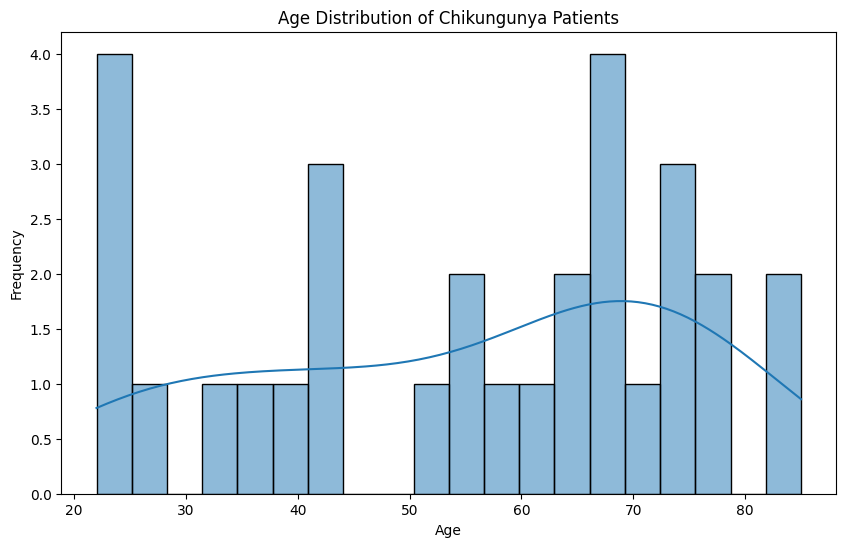

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution of Chikungunya Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig(OUTPUT_DIR / 'age_distribution.png')
plt.show()

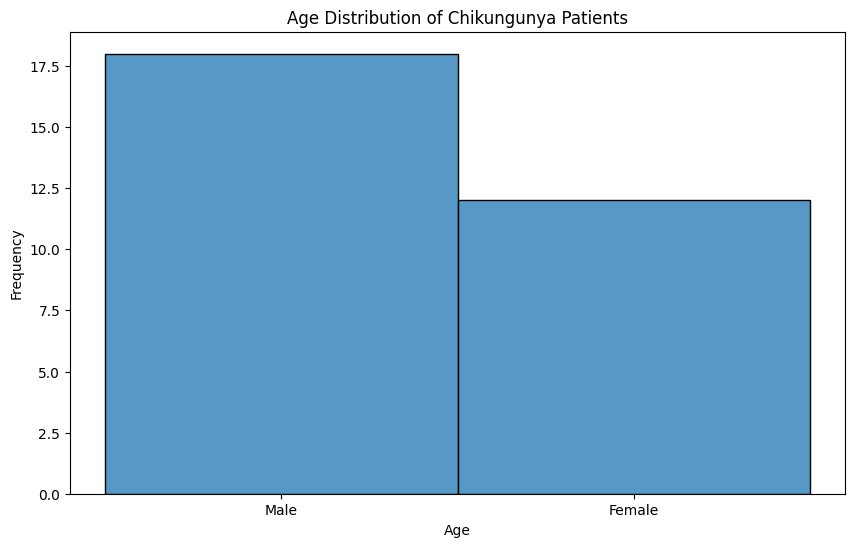

In [134]:
plt.figure(figsize=(10,6))
sns.histplot(df['sex'])
plt.title('Age Distribution of Chikungunya Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig(OUTPUT_DIR / 'age_distribution.png')
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['sex'])
plt.title('Age Distribution of Chikungunya Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig(OUTPUT_DIR / 'age_distribution.png')
plt.show()

In [99]:

def split_columns(df):
    
    # Split blood pressure
    if 'blood_pressure' in df.columns:
        bp_split = df['blood_pressure'].str.split('/', expand=True).astype(float)
        df['systolic_bp'] = bp_split[0]
        df['diastolic_bp'] = bp_split[1]

    # Split semicolon-separated fields
        list_cols = ['presenting_symptoms', 'comorbidities', 'complications', 'diagnostic_test', 'coinfections']
        for col in list_cols:
            if col in df.columns:
                df[col] = df[col].str.split(';')
    return df                

In [110]:
split_columns(df)
df.head()

,timestamp,age,sex,residence,occupation,socioeconomic_status,onset_date,onset_to_admission_duration_in_days,presenting_symptoms,pattern,...,cause_of_death,length_of_stay,readmission_within_30_days,functional_status_at_discharge,duration,inotropic_support,mechanical_ventilation,renal_replacement_therapy,systolic_bp,diastolic_bp
0,2025/10/08 1:41:40 AM GMT+5:30,57,Male,Local,NaN,NaN,2023-12-25,7.0,NaN,NaN,...,NaN,13.0,No,Assisted,13.0,Yes,Yes,No,120.0,70.0
1,2025/10/08 1:49:35 AM GMT+5:30,77,Male,Local,NaN,NaN,2024-04-08,1.0,NaN,NaN,...,NaN,NaN,No,Independent,NaN,No,No,No,140.0,70.0
2,2025/10/08 1:54:41 AM GMT+5:30,55,Male,Local,NaN,NaN,2025-05-03,3.0,NaN,NaN,...,NaN,NaN,No,Independent,NaN,No,No,No,120.0,70.0
3,2025/10/08 2:31:14 AM GMT+5:30,54,Female,Local,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,8.0,No,Independent,6.0,Yes,No,No,110.0,70.0
4,2025/10/08 2:40:36 AM GMT+5:30,65,Female,Local,NaN,NaN,2024-06-12,3.0,NaN,NaN,...,NaN,4.0,No,Independent,NaN,No,No,No,160.0,90.0


In [109]:
df[0:5]['systolic_bp']

0    120.0
1    140.0
2    120.0
3    110.0
4    160.0
Name: systolic_bp, dtype: float64

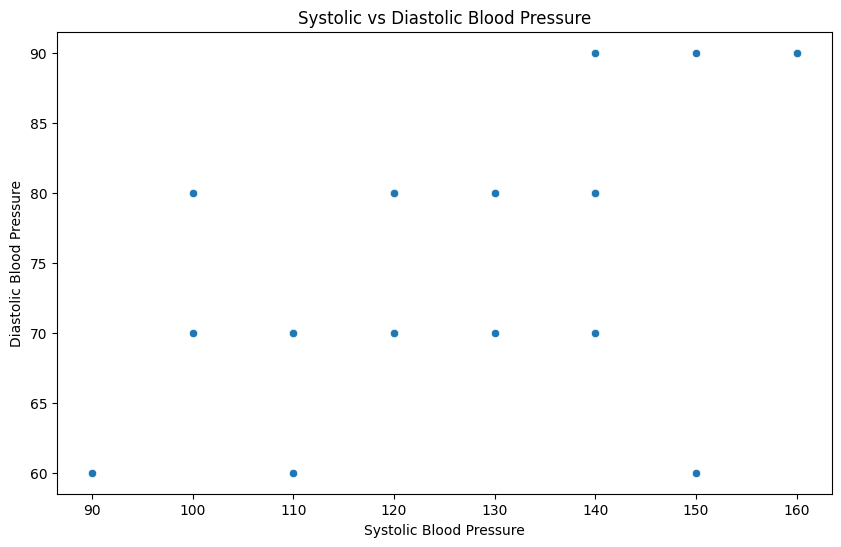

In [112]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='systolic_bp', y='diastolic_bp', data=df)
plt.title('Systolic vs Diastolic Blood Pressure')
plt.xlabel('Systolic Blood Pressure')
plt.ylabel('Diastolic Blood Pressure')
plt.savefig(OUTPUT_DIR / 'bp_scatter.png')
plt.show()

<Axes: xlabel='systolic_bp', ylabel='Count'>

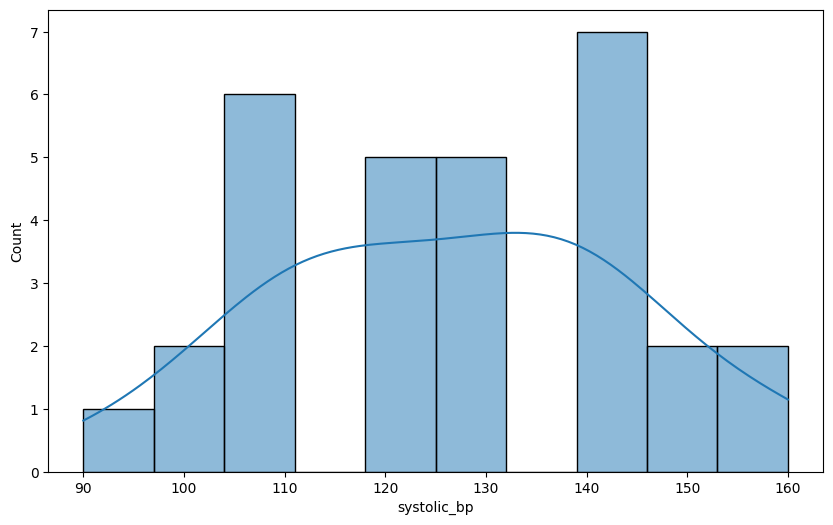

In [118]:
plt.figure(figsize=(10,6))
sns.histplot(df['systolic_bp'], bins=10, kde=True)


<Axes: xlabel='diastolic_bp', ylabel='Count'>

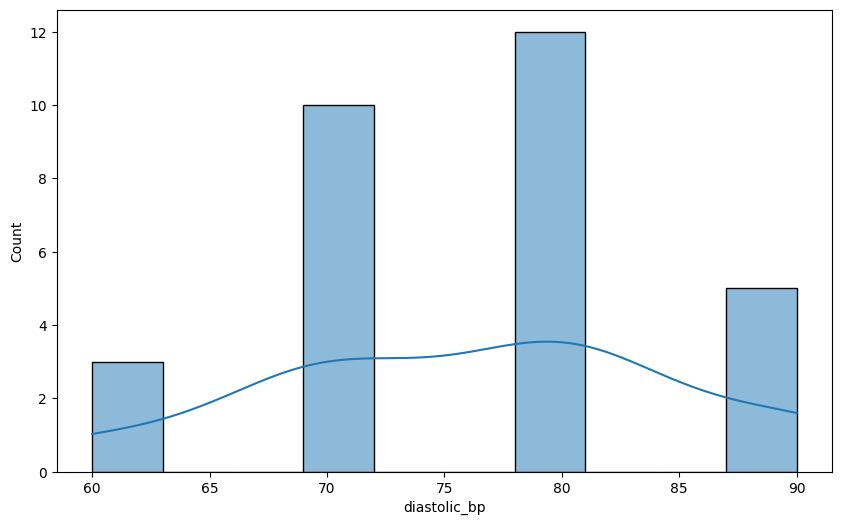

In [120]:
plt.figure(figsize=(10,6))
sns.histplot(df['diastolic_bp'], bins=10, kde=True)

In [128]:
# Correlation

def create_correlation_matrix(df):
    """Create and save correlation matrix for numeric features."""
    # Select numeric columns
    numeric_cols = ['age', 'pulse', 'systolic_bp', 'diastolic_bp', 'spo2', 'respiratory_rate']
    
    # Add binary outcomes for correlation
    df['mortality_binary'] = df['mortality'].str.lower().eq('yes').fillna(False).astype(int)
    df['icu_binary'] = df['icu_admission'].str.lower().eq('yes').fillna(False).astype(int)
    
    # Combine
    corr_cols = numeric_cols + ['mortality_binary', 'icu_binary']
    corr_df = df[corr_cols].dropna()
    
    if corr_df.empty:
        print("No data for correlation matrix.")
        return
    
    # Compute correlation
    corr_matrix = corr_df.corr()
    
    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Matrix: Numeric Features vs Outcomes')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'correlation_matrix.png')
    plt.show()
    
    # Save to CSV
    corr_matrix.to_csv(OUTPUT_DIR / 'correlation_matrix.csv')
    
    print("Correlation matrix saved to outputs/correlation_matrix.png and .csv")


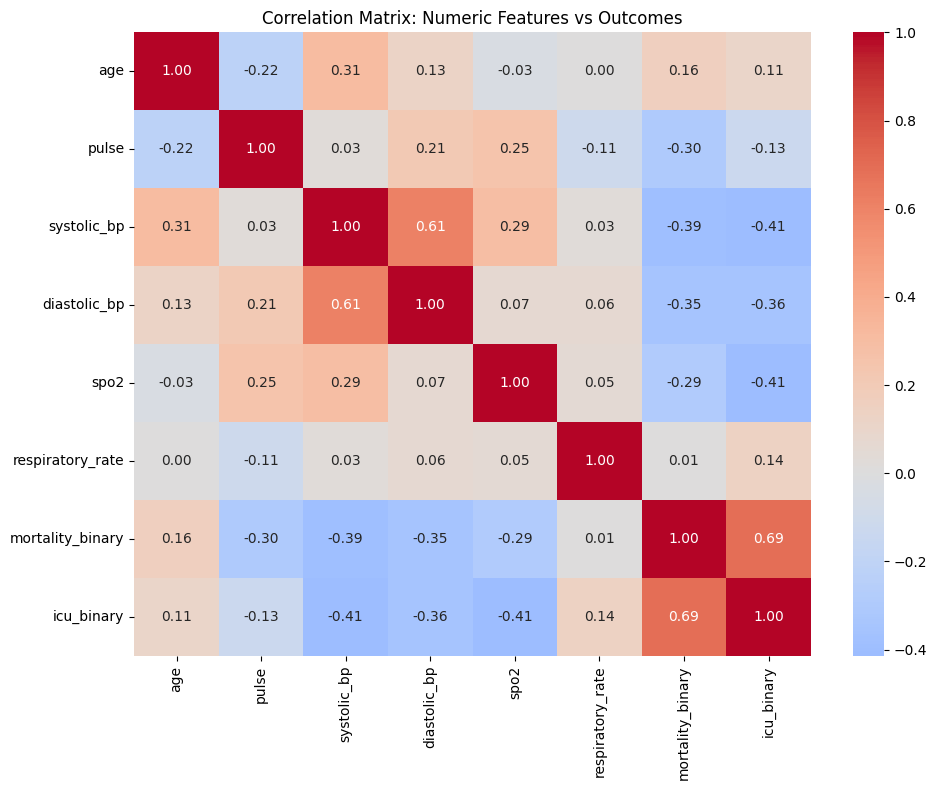

Correlation matrix saved to outputs/correlation_matrix.png and .csv


In [129]:
create_correlation_matrix(df)

In [130]:
def calculate_prevalence(df):
    """Calculate prevalence metrics."""
    results = {}
    
    # Overall
    results['total_cases'] = len(df)
    results['overall_prevalence'] = 1.0  # All are cases
    
    # By sex
    sex_counts = df['sex'].value_counts()
    results['sex_prevalence'] = (sex_counts / len(df)).to_dict()
    
    # By residence
    residence_counts = df['residence'].value_counts()
    results['residence_prevalence'] = (residence_counts / len(df)).to_dict()
    
    # By age groups
    df['age_group'] = pd.cut(df['age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 100], labels=['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81+'])
    age_counts = df['age_group'].value_counts()
    results['age_group_prevalence'] = (age_counts / len(df)).to_dict()
    
    # By comorbidity
    comorbidity_counts = df['comorbidities'].explode().value_counts()
    results['comorbidity_prevalence'] = (comorbidity_counts / len(df)).to_dict()
    
    # By complications
    complication_counts = df['complications'].explode().value_counts()
    results['complication_prevalence'] = (complication_counts / len(df)).to_dict()
    
    # Time-based incidence (by month)
    df['onset_month'] = df['onset_date'].dt.to_period('M')
    monthly_counts = df.groupby('onset_month').size()
    results['monthly_incidence'] = monthly_counts.to_dict()
    
    # Save to CSV
    pd.DataFrame.from_dict(results, orient='index').to_csv(OUTPUT_DIR / 'prevalence_summary.csv')
    
    print("Prevalence calculations saved to outputs/prevalence_summary.csv")
    return results

prevalence_results = calculate_prevalence(df)

Prevalence calculations saved to outputs/prevalence_summary.csv


In [131]:
prevalence_results

{'total_cases': 30,
 'overall_prevalence': 1.0,
 'sex_prevalence': {'Male': 0.6, 'Female': 0.4},
 'residence_prevalence': {'Local': 0.9333333333333333,
  'Native of non endemic area': 0.06666666666666667},
 'age_group_prevalence': {'61-70': 0.23333333333333334,
  '71-80': 0.2,
  '21-30': 0.16666666666666666,
  '51-60': 0.13333333333333333,
  '31-40': 0.1,
  '41-50': 0.1,
  '81+': 0.06666666666666667,
  '0-10': 0.0,
  '11-20': 0.0},
 'comorbidity_prevalence': {},
 'complication_prevalence': {},
 'monthly_incidence': {Period('2023-12', 'M'): 1,
  Period('2024-04', 'M'): 1,
  Period('2024-06', 'M'): 1,
  Period('2024-07', 'M'): 5,
  Period('2024-08', 'M'): 12,
  Period('2024-09', 'M'): 4,
  Period('2025-05', 'M'): 1}}